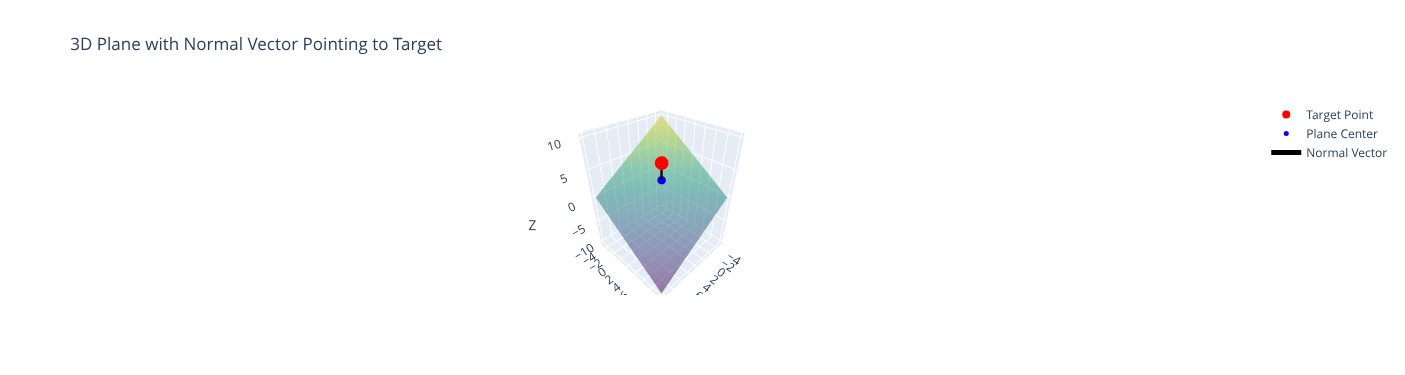

In [ ]:
import numpy as np
import plotly.graph_objects as go

# 1. DEFINITIONS
# The point floating in space
target_point = np.array([5, 5, 8]) 

# The point where the plane is located (and where the normal starts)
plane_center = np.array([1, 1, 2])

# Calculate the Normal Vector (Direction from plane to target)
normal = target_point - plane_center

# 2. GENERATE PLANE DATA
# Equation of plane: a(x-x0) + b(y-y0) + c(z-z0) = 0
# z = z0 - (a(x-x0) + b(y-y0)) / c
x_range = np.linspace(-5, 10, 10)
y_range = np.linspace(-5, 10, 10)
X, Y = np.meshgrid(x_range, y_range)

a, b, c = normal
x0, y0, z0 = plane_center

# Calculate Z for the plane
# (We add a tiny epsilon to c to avoid division by zero if vector is flat)
Z = z0 - (a * (X - x0) + b * (Y - y0)) / (c + 1e-9)

# 3. PLOTTING
fig = go.Figure()

# Add the Plane
fig.add_trace(go.Surface(x=X, y=Y, z=Z, opacity=0.5, colorscale='Viridis', showscale=False, name='Plane'))

# Add the Target Point
fig.add_trace(go.Scatter3d(
    x=[target_point[0]], y=[target_point[1]], z=[target_point[2]],
    mode='markers', marker=dict(size=8, color='red'), name='Target Point'
))

# Add the Point on the Plane (Base of normal)
fig.add_trace(go.Scatter3d(
    x=[plane_center[0]], y=[plane_center[1]], z=[plane_center[2]],
    mode='markers', marker=dict(size=5, color='blue'), name='Plane Center'
))

# Add the Normal Vector (Arrow)
# Plotly uses specific "Cone" traces for 3D vectors or we can draw a line
fig.add_trace(go.Scatter3d(
    x=[plane_center[0], target_point[0]],
    y=[plane_center[1], target_point[1]],
    z=[plane_center[2], target_point[2]],
    mode='lines', line=dict(color='black', width=5), name='Normal Vector'
))

# Add a Cone at the tip to look like an arrow
fig.add_trace(go.Cone(
    x=[target_point[0]], y=[target_point[1]], z=[target_point[2]],
    u=[normal[0]], v=[normal[1]], w=[normal[2]],
    sizemode="absolute", sizeref=0.5, anchor="tip", colorscale=[[0, 'black'], [1, 'black']], showscale=False
))

# Layout settings for real aspect ratio
fig.update_layout(
    title="3D Plane with Normal Vector Pointing to Target",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data' # Important so the vector doesn't look distorted
    )
)

fig.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. SETUP DATA
p_target = np.array([3, 4, 6])   # The point in space
p_plane = np.array([1, 1, 1])    # Point on the plane
normal = p_target - p_plane      # Vector pointing to target

# 2. CREATE PLANE MESH
x = np.linspace(-2, 6, 10)
y = np.linspace(-2, 6, 10)
X, Y = np.meshgrid(x, y)

a, b, c = normal
x0, y0, z0 = p_plane

# Solve plane equation for Z
Z = z0 - (a*(X-x0) + b*(Y-y0)) / (c + 1e-9)

# 3. PLOT
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Surface (Plane)
ax.plot_surface(X, Y, Z, alpha=0.5, rstride=100, cstride=100, color='cyan')

# Plot Points
ax.scatter(*p_target, color='red', s=100, label='Target Point')
ax.scatter(*p_plane, color='blue', s=50, label='Plane Center')

# Plot Normal Vector (Quiver)
# arguments: x, y, z, u, v, w
ax.quiver(p_plane[0], p_plane[1], p_plane[2], 
          normal[0], normal[1], normal[2], 
          color='black', length=1, arrow_length_ratio=0.1, label='Normal')

# 4. COSMETICS
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Plane with Normal pointing to Point')

# Ensure the aspect ratio is equal (so the math looks visually correct)
ax.set_box_aspect([1,1,1]) 

plt.legend()
plt.show()